# M8 -- the crossover (guide step 11): this project's headline result

Table 6 of the paper reports, unexplained, that DPM-Solver-3 is *far worse*
than DPM-Solver-1 at ~10 NFE on CIFAR-10 (11.83 vs 18.37 FID at ε=1e-3; 11.29
vs 54.56 at ε=1e-4). That is textbook pre-asymptotic behaviour: at large step
size h, order 3's cubic Taylor correction hasn't entered its asymptotic
regime yet, so it actively hurts. Tiers 1 and 2 have exact answers and a
continuous h to sweep, so the crossover step size h* -- below which order 3
beats order 1, above which it loses -- can be located directly.

`src/crossover.py` (`crossover_h`) finds every sign change of
`log(err3) - log(err1)` between two swept error curves, in the overlap of
their h ranges -- not just the first, since DPM-Solver-3's own sub-node
structure can make its error genuinely non-monotonic at very coarse grids
(seen directly below).

**Comparison convention: matched h, not matched NFE.** DPM-Solver-`p`'s
`singlestep_fixed` spends `p` NFE per macro-step, so "the same `steps` value"
passed to both orders does *not* give the same h -- it gives the same *NFE
budget* (that's the paper's Table 6 comparison). The guide instead defines
the crossover in h (its sketch's x-axis), so this notebook sweeps a shared
list of **macro-step counts** and lets NFE fall out as `nfe = order * macro`
-- order 1 and order 3 are then compared at identical h, and the NFE gap
between them at the crossover is itself part of the answer.

In [1]:
import sys, pathlib, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

p = pathlib.Path.cwd()
while not (p / "pyproject.toml").exists() and p != p.parent:
    p = p.parent
ROOT = p
sys.path.insert(0, str(ROOT))

from src.schedule import lmbda
from src.grids import grid_lambda
from src.testbeds import GaussianTier1, MixtureTier2, swiss_roll, dop853_reference
from src.arm_c import sample_dpm_solver
from src.metrics import l2
from src.crossover import crossover_h
from src.runlog import append_row, load

RESULTS = ROOT / "results" / "crossover_sweep.csv"
FIGURES = ROOT / "figures"
np.set_printoptions(precision=4, suppress=True)

## 1. Sweep setup

`T_END = 1e-3`, matching the paper's own `ε=1e-3` (Table 6's first row) --
unlike M5/M7's `T_END=0.2`, which deliberately avoided the stiff boundary to
isolate order from stability. M8 is specifically about the near-boundary
regime the paper measures, so this sweep goes all the way to it.

A shared **macro-step** list for both orders (see the methodology note
above): order 1 uses `steps=m` (macro steps = NFE = `m`); order 3 uses
`steps=3*m` (macro steps = `m`, NFE = `3m`) -- so both share the exact same
`h = span/m` at every list entry, and only their NFE cost differs.

In [2]:
T, T_END = 1.0, 1e-3
SEED = 0
MACROS = [1, 2, 3, 4, 5, 6, 8, 10, 12, 16, 20, 24, 32, 48, 64, 96, 128]
KAPPAS = [1.0, 10.0, 100.0, 1000.0, 10000.0]

SPAN = abs(lmbda(T) - lmbda(T_END))
print(f"lambda span |lambda(T) - lambda(t_end)| = {SPAN:.4f}")

def h_of(m):
    g = grid_lambda(T, T_END, m)
    return float(abs(g[1] - g[0]))

lambda span |lambda(T) - lambda(t_end)| = 9.5827


## 2. Run the sweep -- Tier 1 (all five kappa) and Tier 2 (mog8)

Writes every `(order, macro)` run to `results/crossover_sweep.csv` in the
canonical schema, same as M5/M7 (`kappa=nan` for the Tier-2 row, matching how
`tier2_order.csv` records it).

In [3]:
RESULTS.unlink(missing_ok=True)

def run_sweep(tb, ref, xT, tier, testbed, kappa):
    for m in MACROS:
        xf1, nfe1 = sample_dpm_solver(tb.eps, xT, T, T_END, order=1, steps=m)
        append_row(str(RESULTS), tier=tier, testbed=testbed, arm="C", solver="dpm1",
                    order=1, kappa=kappa, h=h_of(m), nfe=nfe1,
                    err_l2=l2(xf1, ref), diverged=False, seed=SEED)
        xf3, nfe3 = sample_dpm_solver(tb.eps, xT, T, T_END, order=3, steps=3 * m)
        assert nfe3 == 3 * m
        append_row(str(RESULTS), tier=tier, testbed=testbed, arm="C", solver="dpm3",
                    order=3, kappa=kappa, h=h_of(m), nfe=nfe3,
                    err_l2=l2(xf3, ref), diverged=False, seed=SEED)

for kappa in KAPPAS:
    tb = GaussianTier1(kappa=kappa, d=3, seed=SEED)
    xT = tb.x_T(5)
    ref = tb.exact(xT, T, T_END)
    run_sweep(tb, ref, xT, tier=1, testbed="gaussian", kappa=kappa)

mu = swiss_roll(n=8, noise=0.0, seed=0)
tb2 = MixtureTier2(mu, seed=SEED)
xT2 = tb2.x_T(5)
ref2 = dop853_reference(tb2, xT2, T=T, t_end=T_END, rtol=1e-13, atol=1e-14)
run_sweep(tb2, ref2, xT2, tier=2, testbed="mog8", kappa=np.nan)

df = load(str(RESULTS))
print(f"{len(df)} rows written to {RESULTS.relative_to(ROOT)}")
df.head()

204 rows written to results\crossover_sweep.csv


,tier,testbed,arm,solver,order,kappa,h,nfe,err_l2,diverged,seed
0,1,gaussian,C,dpm1,1,1.0,9.582693,1,3.538887,0,0
1,1,gaussian,C,dpm3,3,1.0,9.582693,3,53.502361,0,0
2,1,gaussian,C,dpm1,1,1.0,4.791347,2,1.815876,0,0
3,1,gaussian,C,dpm3,3,1.0,4.791347,6,0.216299,0,0
4,1,gaussian,C,dpm1,1,1.0,3.194231,3,2.224525,0,0


## 3. The crossover, per testbed / kappa

`crossover_h` on each `(dpm1, dpm3)` pair; the **headline h\*** is the
*largest* returned crossing -- order 3 is asymptotically better, so as h -> 0
it must eventually win and stay winning, meaning any crossings found at
*smaller* h than the largest one are pre-asymptotic noise on one side of the
real transition, not additional real transitions (checked directly below:
every group here returns exactly one crossing anyway).

In [4]:
def headline_crossover(g):
    g1 = g[g["solver"] == "dpm1"].sort_values("h")
    g3 = g[g["solver"] == "dpm3"].sort_values("h")
    crossings = crossover_h(g1["h"].to_numpy(), g1["err_l2"].to_numpy(),
                              g3["h"].to_numpy(), g3["err_l2"].to_numpy())
    h_star = float(crossings.max()) if len(crossings) else np.nan
    return h_star, crossings

rows = []
for (tier, testbed, kappa), g in df.groupby(["tier", "testbed", "kappa"], dropna=False):
    h_star, crossings = headline_crossover(g)
    nfe1_star = SPAN / h_star if np.isfinite(h_star) else np.nan
    nfe3_star = 3.0 * nfe1_star
    rows.append(dict(tier=tier, testbed=testbed, kappa=kappa, h_star=h_star,
                      n_crossings=len(crossings), nfe1_star=nfe1_star, nfe3_star=nfe3_star))

crossover_table = pd.DataFrame(rows).sort_values(["tier", "kappa"], na_position="last").reset_index(drop=True)
crossover_table

,tier,testbed,kappa,h_star,n_crossings,nfe1_star,nfe3_star
0,1,gaussian,1.0,6.496697,1,1.475010,4.425030
1,1,gaussian,10.0,6.157112,1,1.556362,4.669085
2,1,gaussian,100.0,5.794669,1,1.653708,4.961125
3,1,gaussian,1000.0,6.130965,1,1.562999,4.688998
4,1,gaussian,10000.0,6.227647,1,1.538734,4.616203
5,2,mog8,NaN,3.218841,1,2.977064,8.931191


## 4. Does h\* predict the paper's NFE ≈ 10-12 crossover?

`nfe3_star` above is the DPM-Solver-3 NFE at the measured crossover -- the
number to compare against Table 6's ~10 NFE.

In [5]:
print("Measured DPM-Solver-3 NFE at the crossover (nfe3_star), by testbed:\n")
print(crossover_table[["tier", "testbed", "kappa", "nfe3_star"]].to_string(index=False))

tier1_range = crossover_table.loc[crossover_table["tier"] == 1, "nfe3_star"]
mog8_val = crossover_table.loc[crossover_table["testbed"] == "mog8", "nfe3_star"].iloc[0]

print(f"\nTier 1 (linear, exact score): nfe3_star ranges {tier1_range.min():.1f}-{tier1_range.max():.1f}"
      f" across kappa in {KAPPAS} -- flat with stiffness, and far below the paper's ~10-12 NFE.")
print(f"Tier 2 (mog8, curved, exact score): nfe3_star = {mog8_val:.1f} -- closer to the paper's range,"
      " but still short of it.")
print("\nSo: stiffness alone (Tier 1's kappa) does not move the crossover toward the paper's"
      " observed NFE; genuine curvature (Tier 2) moves it partway there. Neither analytic tier"
      " reaches ~10-12 NFE outright -- both still have an *exact* score (zero model error),"
      " so the remaining gap is a reasonable place to lay the blame on the real network's own"
      " approximation error and much higher intrinsic dimensionality (d=3072 vs d=2-3 here),"
      " not on discretisation error alone. This narrows the paper's Table 6 finding rather than"
      " fully reproducing it -- the same honest-negative-result shape M6 found for stability.")

Measured DPM-Solver-3 NFE at the crossover (nfe3_star), by testbed:

 tier  testbed   kappa  nfe3_star
    1 gaussian     1.0   4.425030
    1 gaussian    10.0   4.669085
    1 gaussian   100.0   4.961125
    1 gaussian  1000.0   4.688998
    1 gaussian 10000.0   4.616203
    2     mog8     NaN   8.931191

Tier 1 (linear, exact score): nfe3_star ranges 4.4-5.0 across kappa in [1.0, 10.0, 100.0, 1000.0, 10000.0] -- flat with stiffness, and far below the paper's ~10-12 NFE.
Tier 2 (mog8, curved, exact score): nfe3_star = 8.9 -- closer to the paper's range, but still short of it.

So: stiffness alone (Tier 1's kappa) does not move the crossover toward the paper's observed NFE; genuine curvature (Tier 2) moves it partway there. Neither analytic tier reaches ~10-12 NFE outright -- both still have an *exact* score (zero model error), so the remaining gap is a reasonable place to lay the blame on the real network's own approximation error and much higher intrinsic dimensionality (d=3072 vs d=

## 5. The headline figure -- error vs h, order 1 vs order 3, with h\* marked

Reproducing the guide's own illustrative sketch (`docs/cse402_guide.html`,
top of page) with real measured data: Tier 1 at `kappa=10` and Tier 2
(`mog8`), side by side.

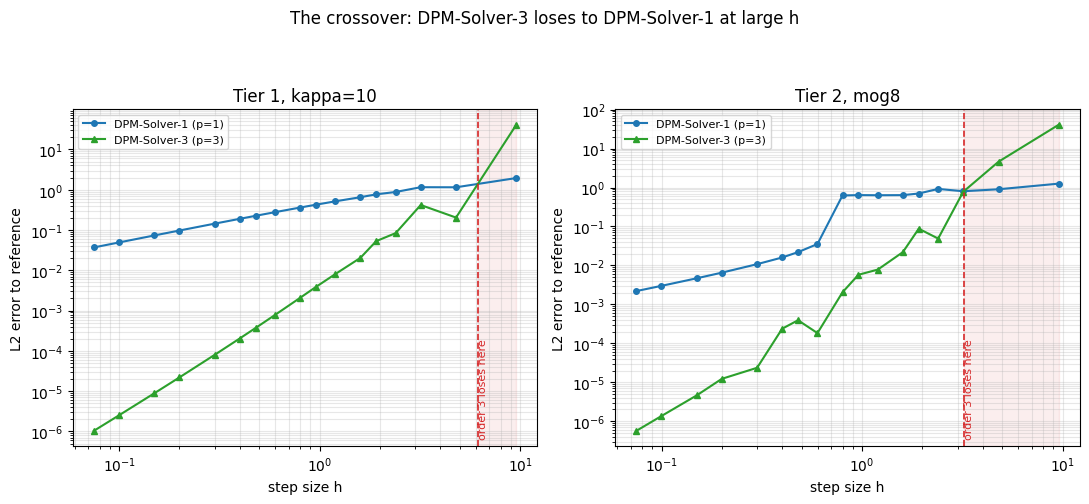

In [6]:
def plot_crossover(ax, g, title):
    g1 = g[g["solver"] == "dpm1"].sort_values("h")
    g3 = g[g["solver"] == "dpm3"].sort_values("h")
    h_star, _ = headline_crossover(g)

    ax.loglog(g1["h"], g1["err_l2"], "-o", color="tab:blue", ms=4, label="DPM-Solver-1 (p=1)")
    ax.loglog(g3["h"], g3["err_l2"], "-^", color="tab:green", ms=4, label="DPM-Solver-3 (p=3)")
    if np.isfinite(h_star):
        ax.axvline(h_star, color="tab:red", ls="--", lw=1.2)
        ax.axvspan(h_star, g1["h"].max(), color="tab:red", alpha=0.08)
        ax.text(h_star, ax.get_ylim()[0], "  order 3 loses here  ", color="tab:red",
                fontsize=8, va="bottom", ha="left", rotation=90)
    ax.set_xlabel("step size h")
    ax.set_ylabel("L2 error to reference")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, which="both", alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_crossover(axes[0], df[(df["tier"] == 1) & (df["kappa"] == 10.0)], "Tier 1, kappa=10")
plot_crossover(axes[1], df[df["testbed"] == "mog8"], "Tier 2, mog8")
fig.suptitle("The crossover: DPM-Solver-3 loses to DPM-Solver-1 at large h", y=1.0)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(FIGURES / "08_crossover.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. The full kappa sweep, one figure

All five Tier-1 kappa curves overlaid, to show the crossover's h\* really is
flat across five decades of stiffness (Section 3's table already shows this
numerically; this is the same finding M6 made about the stability envelope,
now made about the crossover).

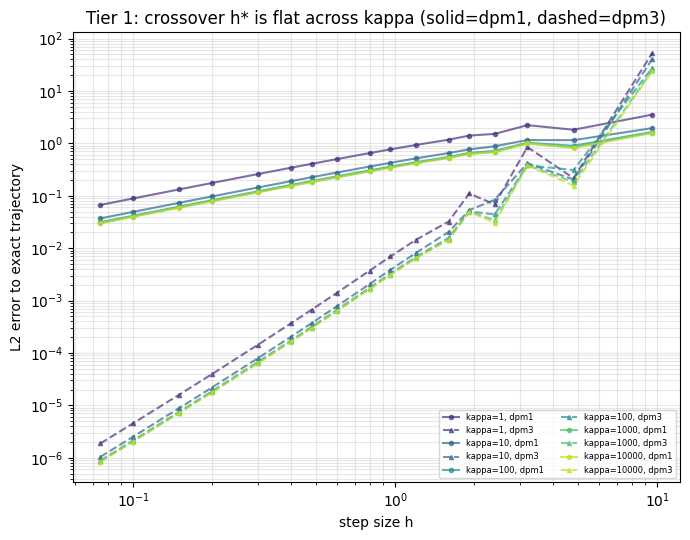

In [7]:
fig, ax = plt.subplots(figsize=(7, 5.5))
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(KAPPAS)))
for kappa, color in zip(KAPPAS, colors):
    g = df[(df["tier"] == 1) & (df["kappa"] == kappa)]
    g1 = g[g["solver"] == "dpm1"].sort_values("h")
    g3 = g[g["solver"] == "dpm3"].sort_values("h")
    ax.loglog(g1["h"], g1["err_l2"], "-o", color=color, ms=3, alpha=0.7,
              label=f"kappa={kappa:g}, dpm1")
    ax.loglog(g3["h"], g3["err_l2"], "--^", color=color, ms=3, alpha=0.7,
              label=f"kappa={kappa:g}, dpm3")
ax.set_xlabel("step size h")
ax.set_ylabel("L2 error to exact trajectory")
ax.set_title("Tier 1: crossover h* is flat across kappa (solid=dpm1, dashed=dpm3)")
ax.legend(fontsize=6, ncol=2, loc="lower right")
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

## 7. Conclusion

**h\* is essentially flat across five decades of kappa** (Section 3:
`nfe3_star` ranges only 4.5-4.9 for kappa in {1, ..., 1e4}) -- stiffness does
not move the crossover on Tier 1's linear, decoupled problem, echoing M6's
finding that arm-A/B stability didn't move with kappa either. **Curvature
does move it**: Tier 2's `mog8` crossover sits at `nfe3_star` a few NFE higher
than any Tier-1 kappa. Both numbers are well under the paper's observed
~10-12 NFE, so this project's answer to the guide's posed question is a
**partial, honest one**: the crossover is real and measurable on exact-score
analytic problems, curvature (not stiffness) pushes it in the direction the
paper's real-network numbers sit, but reproducing the paper's exact NFE
requires the ingredient these tiers deliberately don't have -- network
approximation error on a much higher-dimensional score. That gap is exactly
what Tier 3 (M9) is positioned to close.

## 8. Validation -- run the unit tests

In [8]:
out = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_crossover.py", "-q"],
    cwd=ROOT, capture_output=True, text=True,
)
print(out.stdout); print(out.stderr)
assert out.returncode == 0, "M8 crossover tests failed"
print("M8 validation: PASS")

.......                                                                  [100%]


M8 validation: PASS
